In [2]:
import pandas as pd

df = pd.read_csv("customer_rfm_segmented.csv")

df.head()

,CustomerID,Recency,Frequency,Monetary,Segment
0,12346.0,165,11,372.86,Lost
1,12347.0,3,2,1323.32,Champions
2,12348.0,74,1,222.16,At Risk
3,12349.0,43,3,2671.14,At Risk
4,12351.0,11,1,300.93,Champions


In [3]:
df["Purchase30Days"] = (df["Recency"] <= 30).astype(int)

df.head()

,CustomerID,Recency,Frequency,Monetary,Segment,Purchase30Days
0,12346.0,165,11,372.86,Lost,0
1,12347.0,3,2,1323.32,Champions,1
2,12348.0,74,1,222.16,At Risk,0
3,12349.0,43,3,2671.14,At Risk,0
4,12351.0,11,1,300.93,Champions,1


In [5]:
X = df[["Recency", "Frequency", "Monetary"]]

y = df["Purchase30Days"]

print(X.head())

print(y.head())

   Recency  Frequency  Monetary
0      165         11    372.86
1        3          2   1323.32
2       74          1    222.16
3       43          3   2671.14
4       11          1    300.93
0    0
1    1
2    0
3    0
4    1
Name: Purchase30Days, dtype: int32


In [6]:
from sklearn.model_selection import train_test_split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [8]:
print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

print("Training Labels:", y_train.shape)
print("Testing Labels:", y_test.shape)

Training Data: (3449, 3)
Testing Data: (863, 3)
Training Labels: (3449,)
Testing Labels: (863,)


In [9]:
from sklearn.linear_model import LogisticRegression

In [10]:
model = LogisticRegression()

model.fit(X_train, y_train)

LogisticRegression()

In [11]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[1 0 1 0 0 1 0 0 0 1]


In [12]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 1.0


**Day 19**

In [13]:
from sklearn.metrics import accuracy_score, f1_score

In [14]:
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("F1 Score:", f1)

Accuracy: 1.0
F1 Score: 1.0


In [15]:
import matplotlib.pyplot as plt
import pandas as pd

In [16]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": abs(model.coef_[0])
})

importance = importance.sort_values(by="Importance", ascending=False)

print(importance)

     Feature  Importance
0    Recency    4.322574
1  Frequency    0.016667
2   Monetary    0.000115


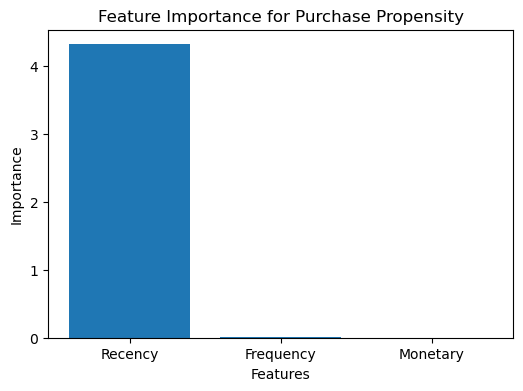

In [17]:
plt.figure(figsize=(6,4))

plt.bar(
    importance["Feature"],
    importance["Importance"]
)

plt.title("Feature Importance for Purchase Propensity")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.show()

In [18]:
import joblib

In [19]:
joblib.dump(model, "purchase_propensity_model.pkl")

print("Model saved successfully!")

Model saved successfully!
